### Implement a linear regression model to predict the prices of houses based on their square footage and the number of bedrooms and bathrooms.

In [1]:
# STEP 1 — Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


In [2]:
# STEP 2 — Load Dataset

data = pd.read_csv("train.csv")

In [3]:
# STEP 3 — Select Required Features

features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
target = 'SalePrice'

X = data[features]
y = data[target]

In [4]:

# STEP 4 — Check Missing Values

print(X.isnull().sum())

GrLivArea       0
BedroomAbvGr    0
FullBath        0
dtype: int64


In [5]:
# STEP 5 — Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
# STEP 6 — Create Model

model = LinearRegression()

In [7]:
# STEP 7 — Train Model

model.fit(X_train, y_train)

LinearRegression()

In [8]:
# STEP 8 — Make Predictions

predictions = model.predict(X_test)

In [9]:
# STEP 9 — Evaluate Model

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\nModel Performance")
print("-------------------")
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


Model Performance
-------------------
Mean Absolute Error: 35788.0612924363
R2 Score: 0.6341189942328371


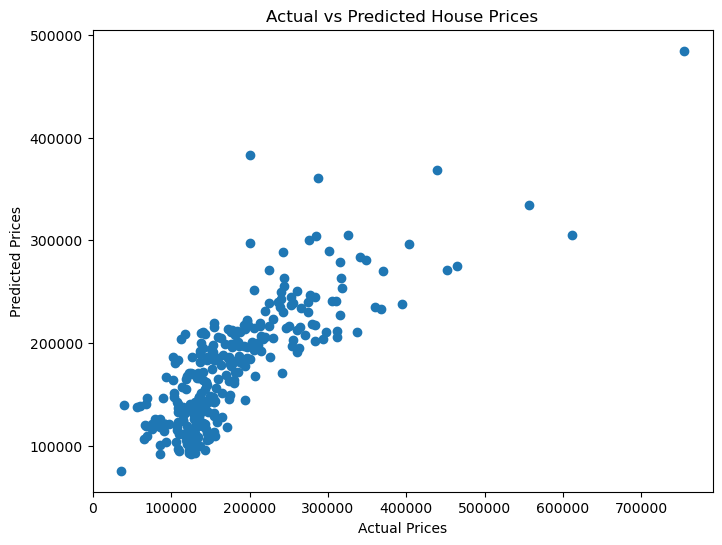

In [11]:
# STEP 10 — Visualization

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [13]:
# STEP 11 — Predict New House Price

print("\nEnter House Details")
user_area = float(input("Enter Square Footage: "))
user_bedrooms = int(input("Enter Number of Bedrooms: "))
user_bathrooms = int(input("Enter Number of Bathrooms: "))

# Create Input Array
user_house = pd.DataFrame(
    [[user_area, user_bedrooms, user_bathrooms]],
    columns=['GrLivArea', 'BedroomAbvGr', 'FullBath']
)
# Predict Price
user_prediction = model.predict(user_house)

print("\nEstimated House Price:")
print(f"${user_prediction[0]:,.2f}")


Enter House Details


Enter Square Footage:  2000
Enter Number of Bedrooms:  5
Enter Number of Bathrooms:  3



Estimated House Price:
$217,081.51
